## 1. Data Import and Setup

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

url = "https://raw.githubusercontent.com/GeethaGunasekaran1/Dataset_rep/main/social_media_engagement_5000.csv"
df = pd.read_csv(url)
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [11]:
# Check data types
print(df.dtypes)
print("\nShape:", df.shape)

user_id               int64
age                 float64
gender                  str
country                 str
post_id               int64
post_type               str
post_category           str
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at               str
follower_count        int64
is_verified            bool
device_type             str
sentiment               str
hashtags                str
engagement_rate     float64
dtype: object

Shape: (5000, 19)


In [12]:
# Convert date column to datetime (format in file is dd-mm-yyyy)
df["posted_at"] = pd.to_datetime(df["posted_at"], format="%d-%m-%Y")

# Extra date parts for later analysis
df["post_month"] = df["posted_at"].dt.to_period("M").astype(str)
df["post_weekday"] = df["posted_at"].dt.day_name()
print(df["posted_at"].dtype)
print(df["posted_at"].min(), "to", df["posted_at"].max())

datetime64[us]
2022-01-01 00:00:00 to 2023-12-31 00:00:00


In [13]:
# Basic NumPy array operations
likes_arr = df["likes"].to_numpy()
print("Array shape      :", likes_arr.shape)
print("Mean likes       :", np.nanmean(likes_arr))
print("Max likes        :", np.nanmax(likes_arr))
print("Std dev          :", np.nanstd(likes_arr))

# Vectorised operation: total interactions as a NumPy array
interactions = (df["likes"].to_numpy() + df["comments"].to_numpy() + df["shares"].to_numpy())
print("First 5 interactions:", interactions[:5])
print("Likes above 15000   :", np.sum(likes_arr > 15000))

Array shape      : (5000,)
Mean likes       : 10107.043711340206
Max likes        : 19998.0
Std dev          : 5789.222332204695
First 5 interactions: [ 8522. 16163.  6161.  7482. 16717.]
Likes above 15000   : 1241


## 2. Data Cleaning

In [14]:
print(df.isnull().sum())
print("\nTotal missing cells:", df.isna().sum().sum())

user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
post_month            0
post_weekday          0
dtype: int64

Total missing cells: 900


In [15]:
# Numeric columns -> median (robust to outliers)
for col in ["age", "likes", "comments", "shares"]:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns -> mode
for col in ["gender", "sentiment"]:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum().sum(), "missing values left")

0 missing values left


In [16]:
print("Duplicate rows (full row):", df.duplicated().sum())
print("Duplicate post_id        :", df["post_id"].duplicated().sum())

df = df.drop_duplicates()                      # full-row duplicates
df = df.drop_duplicates(subset="post_id")      # same post twice
df = df.reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Duplicate rows (full row): 0
Duplicate post_id        : 9
Shape after removing duplicates: (4991, 21)


In [17]:
# Fix data types
for col in ["age", "likes", "comments", "shares"]:
    df[col] = df[col].astype(int)

# Standardise category labels (strip spaces, consistent case)
for col in ["gender", "country", "post_type", "post_category", "device_type", "sentiment"]:
    df[col] = df[col].str.strip().str.lower()

df["gender"] = df["gender"].replace({"m": "male", "f": "female"})
df["country"] = df["country"].str.upper().where(df["country"].isin(["usa", "uk", "uae"]), df["country"].str.title())
df["sentiment"] = df["sentiment"].replace({"pos": "positive", "neg": "negative", "neu": "neutral"})

print(df["gender"].unique())
print(df["sentiment"].unique())

<StringArray>
['female', 'male', 'other']
Length: 3, dtype: str
<StringArray>
['negative', 'positive', 'neutral']
Length: 3, dtype: str


In [18]:
# Unrealistic values
print("Negative likes/comments/shares:", ((df[["likes","comments","shares"]] < 0).any(axis=1)).sum())
print("Age outside 13-100            :", (~df["age"].between(13, 100)).sum())

# engagement_rate = (likes+comments+shares)/impressions. A value above 1 (100%)
# means more interactions than impressions, which is impossible.
df["interactions"] = df["likes"] + df["comments"] + df["shares"]
df["unrealistic_flag"] = df["interactions"] > df["impression_count"]
print("Rows where interactions > impressions:", df["unrealistic_flag"].sum(),
      f"({df['unrealistic_flag'].mean():.1%})")

# Cap engagement_rate at 1.0 (100%) instead of throwing away 12% of the data
df["engagement_rate_raw"] = df["engagement_rate"]
df["engagement_rate"] = df["engagement_rate"].clip(upper=1)
print("Max engagement_rate now:", df["engagement_rate"].max())

Negative likes/comments/shares: 0
Age outside 13-100            : 0
Rows where interactions > impressions: 599 (12.0%)
Max engagement_rate now: 1.0


In [19]:
# Hashtag count
df["hashtag_count"] = df["hashtags"].str.count("#")
print(df["hashtag_count"].value_counts().sort_index())

# Sentiment labels are already clean
print(df["sentiment"].value_counts())

hashtag_count
1    1652
2    1692
3    1647
Name: count, dtype: int64
sentiment
positive    2508
neutral     1525
negative     958
Name: count, dtype: int64


## 3. Data Exploration using Pandas

In [20]:
display(df.head())
display(df.tail())
print("Shape:", df.shape)
print("Columns:", list(df.columns))

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,post_month,post_weekday,interactions,unrealistic_flag,engagement_rate_raw,hashtag_count
0,25795,43,female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,2022-12,Saturday,8522,False,0.190862,3
1,10860,33,male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,2023-06,Friday,16163,False,0.201493,1
2,86820,32,female,UK,109864,text,food,4862,344,955,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,2023-05,Sunday,6161,False,0.137345,1
3,64886,51,other,France,848877,text,fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,2023-02,Sunday,7482,False,0.106195,3
4,16265,34,other,UK,449706,image,fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,1.000000,2023-05,Tuesday,16717,True,2.777372,1


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,post_month,post_weekday,interactions,unrealistic_flag,engagement_rate_raw,hashtag_count
4986,59500,44,male,Australia,441541,video,education,16210,2013,1837,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2022-06,Saturday,20060,False,0.466761,2
4987,22100,38,other,UAE,677076,reel,education,16924,2734,1583,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2022-11,Friday,21241,False,0.621155,2
4988,67021,63,female,USA,273595,text,travel,13487,1497,167,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2023-04,Thursday,15151,False,0.679688,2
4989,29800,13,female,Germany,785644,video,fitness,16894,1289,1713,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,2022-05,Monday,19896,False,0.223518,3
4990,73400,54,other,Japan,712252,text,travel,14830,503,1798,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.000000,2023-03,Saturday,17131,True,1.203527,3


Shape: (4991, 25)
Columns: ['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate', 'post_month', 'post_weekday', 'interactions', 'unrealistic_flag', 'engagement_rate_raw', 'hashtag_count']


In [21]:
df.info()
print(df.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 4991 entries, 0 to 4990
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              4991 non-null   int64         
 1   age                  4991 non-null   int64         
 2   gender               4991 non-null   str           
 3   country              4991 non-null   str           
 4   post_id              4991 non-null   int64         
 5   post_type            4991 non-null   str           
 6   post_category        4991 non-null   str           
 7   likes                4991 non-null   int64         
 8   comments             4991 non-null   int64         
 9   shares               4991 non-null   int64         
 10  watch_time_sec       4991 non-null   int64         
 11  impression_count     4991 non-null   int64         
 12  posted_at            4991 non-null   datetime64[us]
 13  follower_count       4991 non-null   int64  

In [22]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,interactions,engagement_rate_raw,hashtag_count
count,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000
mean,54547.943699,38.439591,547854.825486,10105.831897,1501.511921,1002.897015,4015.120617,50029.706872,2022-12-28 10:38:12.286115,393904.683631,0.371150,12610.240834,0.964971,1.998998
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.000000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,193.000000,0.006363,1.000000
25%,32281.000000,26.000000,322410.000000,5224.500000,791.000000,511.000000,2023.500000,24997.000000,2022-07-03 12:00:00,195064.500000,0.145709,7800.000000,0.145709,1.000000
50%,54327.000000,38.000000,547905.000000,10105.000000,1497.000000,1012.000000,4034.000000,49954.000000,2022-12-27 00:00:00,389040.000000,0.253806,12552.000000,0.253806,2.000000
75%,77172.500000,51.000000,771256.500000,14965.000000,2234.500000,1482.500000,6020.500000,74715.500000,2023-06-27 12:00:00,589869.000000,0.504695,17481.500000,0.504695,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,1.000000,24680.000000,191.504348,3.000000
std,26094.658996,14.686923,260657.341322,5703.628075,856.683226,570.842898,2307.053146,28845.669265,NaN,230898.849565,0.304625,5782.928668,5.322732,0.813094


In [23]:
cat_cols = ["gender", "country", "post_type", "post_category", "device_type", "sentiment"]
for col in cat_cols:
    print(f"--- {col} (unique = {df[col].nunique()}) ---")
    print(df[col].unique())
    print(df[col].value_counts(), "\n")

--- gender (unique = 3) ---
<StringArray>
['female', 'male', 'other']
Length: 3, dtype: str
gender
male      1842
other     1581
female    1568
Name: count, dtype: int64 

--- country (unique = 10) ---
<StringArray>
[   'Brazil',        'UK',    'France',    'Canada',     'Japan', 'Australia',
     'India',       'UAE',   'Germany',       'USA']
Length: 10, dtype: str
country
India        534
Canada       512
Brazil       504
UAE          502
USA          501
France       496
UK           491
Australia    490
Germany      489
Japan        472
Name: count, dtype: int64 

--- post_type (unique = 4) ---
<StringArray>
['image', 'reel', 'text', 'video']
Length: 4, dtype: str
post_type
reel     1281
image    1244
text     1243
video    1223
Name: count, dtype: int64 

--- post_category (unique = 8) ---
<StringArray>
[  'fitness',      'food',      'tech',    'travel',   'fashion', 'lifestyle',
 'education',     'music']
Length: 8, dtype: str
post_category
fitness      674
tech         665
mu

In [24]:
num_cols = ["age", "likes", "comments", "shares", "watch_time_sec",
            "impression_count", "follower_count", "engagement_rate", "hashtag_count"]
corr = df[num_cols].corr()
corr

,age,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
age,1.000000,-0.036659,-0.007792,0.013386,0.005189,0.014138,-0.025847,-0.025645,0.007236
likes,-0.036659,1.000000,-0.018987,0.004819,0.007566,0.007205,-0.022435,0.393298,-0.002379
comments,-0.007792,-0.018987,1.000000,0.005410,-0.017197,-0.009278,-0.011117,0.064522,-0.014957
shares,0.013386,0.004819,0.005410,1.000000,0.014394,-0.004695,-0.010922,0.050930,0.013541
watch_time_sec,0.005189,0.007566,-0.017197,0.014394,1.000000,-0.004720,0.004020,0.014027,-0.023231
impression_count,0.014138,0.007205,-0.009278,-0.004695,-0.004720,1.000000,-0.015199,-0.784022,-0.003494
follower_count,-0.025847,-0.022435,-0.011117,-0.010922,0.004020,-0.015199,1.000000,-0.004180,0.008117
engagement_rate,-0.025645,0.393298,0.064522,0.050930,0.014027,-0.784022,-0.004180,1.000000,-0.007406
hashtag_count,0.007236,-0.002379,-0.014957,0.013541,-0.023231,-0.003494,0.008117,-0.007406,1.000000


In [25]:
display(df.groupby("post_type")["likes"].mean().round(0).sort_values(ascending=False))
display(df.groupby("country")["impression_count"].mean().round(0).sort_values(ascending=False))

post_type
video    10188.0
image    10103.0
text     10100.0
reel     10036.0
Name: likes, dtype: float64

country
India        52541.0
France       51728.0
USA          51264.0
UK           51113.0
Japan        49616.0
Brazil       49193.0
UAE          48936.0
Canada       48656.0
Germany      48645.0
Australia    48423.0
Name: impression_count, dtype: float64

## 4. Data Wrangling

In [26]:
# New fields
df["engagement_score"] = df["likes"] + 2 * df["comments"] + 3 * df["shares"]   # weighted
df["log_likes"] = np.log1p(df["likes"])
df["log_impressions"] = np.log1p(df["impression_count"])
df["log_followers"] = np.log1p(df["follower_count"])
df[["likes", "comments", "shares", "engagement_score", "log_likes", "hashtag_count"]].head()

,likes,comments,shares,engagement_score,log_likes,hashtag_count
0,7011,354,1157,11190,8.855378,3
1,11750,2606,1807,22383,9.371694,1
2,4862,344,955,8415,8.489411,1
3,5350,1083,1049,10663,8.585039,3
4,12682,2735,1300,22052,9.448018,1


In [27]:
# groupby summaries
agg = {"likes": "mean", "engagement_score": "mean", "engagement_rate": "mean", "impression_count": "mean"}
by_post_type = df.groupby("post_type").agg(agg).round(3)
by_country   = df.groupby("country").agg(agg).round(3)
by_sentiment = df.groupby("sentiment").agg(agg).round(3)
display(by_post_type); display(by_country); display(by_sentiment)

,likes,engagement_score,engagement_rate,impression_count
post_type,,,,
image,10103.127,16208.592,0.373,49778.921
reel,10036.051,15991.014,0.360,50483.231
text,10099.928,16134.848,0.376,49987.308
video,10187.674,16139.888,0.376,49852.859


,likes,engagement_score,engagement_rate,impression_count
country,,,,
Australia,10294.967,16347.120,0.394,48422.882
Brazil,9886.679,15894.125,0.376,49193.175
Canada,10056.561,16146.051,0.378,48656.490
France,10372.863,16485.692,0.367,51727.673
Germany,10124.155,16103.401,0.379,48645.110
India,9979.622,16070.640,0.340,52540.886
Japan,10088.852,16027.775,0.385,49616.136
UAE,10229.727,16285.241,0.383,48935.631
UK,9915.479,15791.878,0.354,51113.342


,likes,engagement_score,engagement_rate,impression_count
sentiment,,,,
negative,10208.042,16255.356,0.375,50192.504
neutral,9918.558,15965.342,0.374,49528.165
positive,10180.663,16157.455,0.368,50272.487


In [28]:
# merge / concat / join demo: build a country summary and merge it back
country_avg = (df.groupby("country")["engagement_rate"].mean()
                 .rename("country_avg_engagement").reset_index())
df = df.merge(country_avg, on="country", how="left")
df["above_country_avg"] = df["engagement_rate"] > df["country_avg_engagement"]

# concat: stack two summaries side by side
summary = pd.concat([by_post_type["likes"].rename("avg_likes"),
                     by_post_type["engagement_rate"].rename("avg_eng_rate")], axis=1)
summary

,avg_likes,avg_eng_rate
post_type,,
image,10103.127,0.373
reel,10036.051,0.360
text,10099.928,0.376
video,10187.674,0.376


## 5. Statistical Analysis

In [29]:
stat_cols = ["likes", "comments", "shares", "watch_time_sec", "engagement_rate", "follower_count"]
stats = pd.DataFrame({
    "mean": df[stat_cols].mean(),
    "median": df[stat_cols].median(),
    "mode": df[stat_cols].mode().iloc[0],
    "std": df[stat_cols].std(),
    "variance": df[stat_cols].var(),
    "p25": df[stat_cols].quantile(0.25),
    "p50": df[stat_cols].quantile(0.50),
    "p75": df[stat_cols].quantile(0.75),
    "p90": df[stat_cols].quantile(0.90),
    "skewness": df[stat_cols].skew(),
    "kurtosis": df[stat_cols].kurt(),
}).round(3)
stats

,mean,median,mode,std,variance,p25,p50,p75,p90,skewness,kurtosis
likes,10105.832,10105.000,10105.0,5703.628,3.253137e+07,5224.500,10105.000,14965.000,18016.0,-0.006,-1.151
comments,1501.512,1497.000,1497.0,856.683,7.339062e+05,791.000,1497.000,2234.500,2696.0,0.005,-1.145
shares,1002.897,1012.000,1012.0,570.843,3.258616e+05,511.000,1012.000,1482.500,1796.0,-0.013,-1.147
watch_time_sec,4015.121,4034.000,916.0,2307.053,5.322494e+06,2023.500,4034.000,6020.500,7212.0,-0.018,-1.195
engagement_rate,0.371,0.254,1.0,0.305,9.300000e-02,0.146,0.254,0.505,1.0,1.060,-0.192
follower_count,393904.684,389040.000,497502.0,230898.850,5.331428e+10,195064.500,389040.000,589869.000,717827.0,0.040,-1.189


## 6. Data Visualization

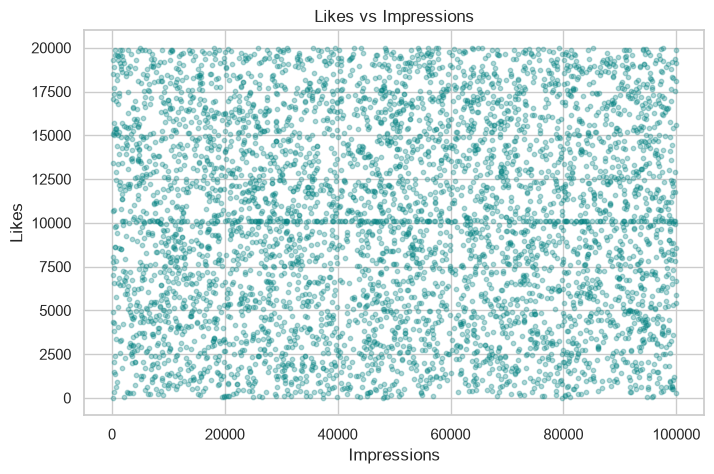

In [30]:
# 1. Scatter: likes vs impressions
plt.figure(figsize=(8, 5))
plt.scatter(df["impression_count"], df["likes"], alpha=0.3, s=10, color="teal")
plt.title("Likes vs Impressions"); plt.xlabel("Impressions"); plt.ylabel("Likes")
plt.show()

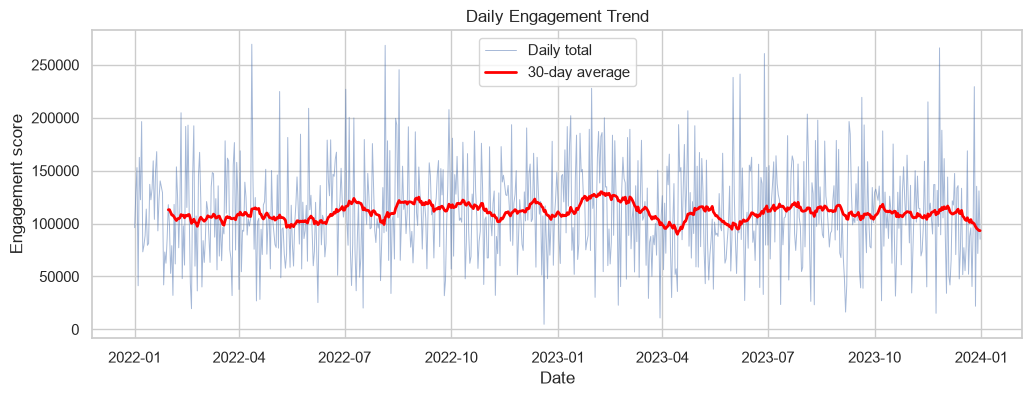

In [31]:
# 2. Line: daily engagement trend (monthly average shown for readability, daily total too)
daily = df.groupby("posted_at")["engagement_score"].sum()
plt.figure(figsize=(12, 4))
plt.plot(daily.index, daily.values, linewidth=0.7, alpha=0.5, label="Daily total")
plt.plot(daily.index, daily.rolling(30).mean(), color="red", linewidth=2, label="30-day average")
plt.title("Daily Engagement Trend"); plt.xlabel("Date"); plt.ylabel("Engagement score")
plt.legend(); plt.show()

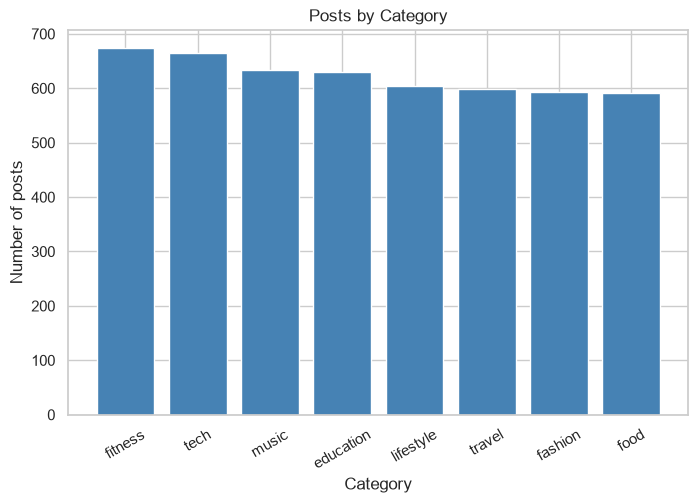

In [32]:
# 3. Bar: posts by category
counts = df["post_category"].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values, color="steelblue")
plt.title("Posts by Category"); plt.xlabel("Category"); plt.ylabel("Number of posts")
plt.xticks(rotation=30); plt.show()

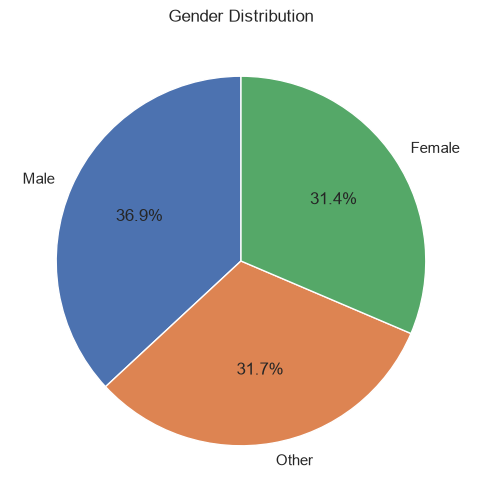

In [33]:
# 4. Pie: gender distribution
g = df["gender"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(g.values, labels=g.index.str.title(), autopct="%1.1f%%", startangle=90)
plt.title("Gender Distribution"); plt.show()

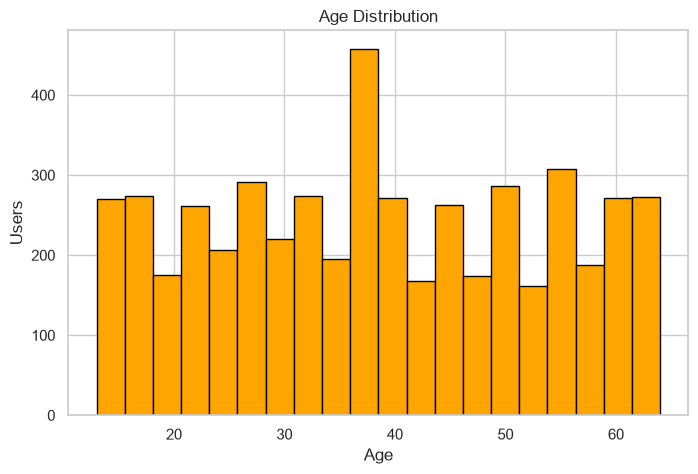

In [34]:
# 5. Histogram: age
plt.figure(figsize=(8, 5))
plt.hist(df["age"], bins=20, color="orange", edgecolor="black")
plt.title("Age Distribution"); plt.xlabel("Age"); plt.ylabel("Users"); plt.show()

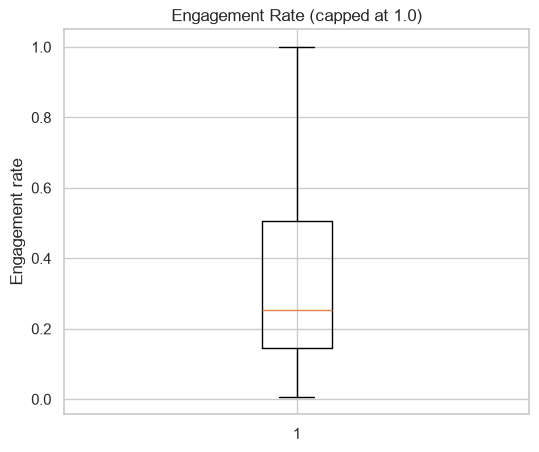

In [35]:
# 6. Box: engagement rate
plt.figure(figsize=(6, 5))
plt.boxplot(df["engagement_rate"], vert=True)
plt.title("Engagement Rate (capped at 1.0)"); plt.ylabel("Engagement rate"); plt.show()

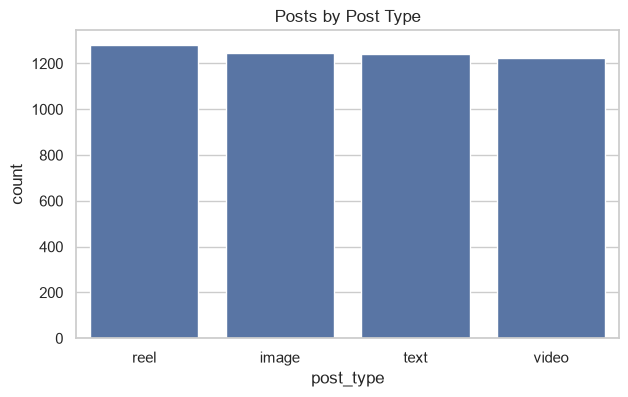

In [36]:
# 7. Count plot: post type
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="post_type", order=df["post_type"].value_counts().index)
plt.title("Posts by Post Type"); plt.show()

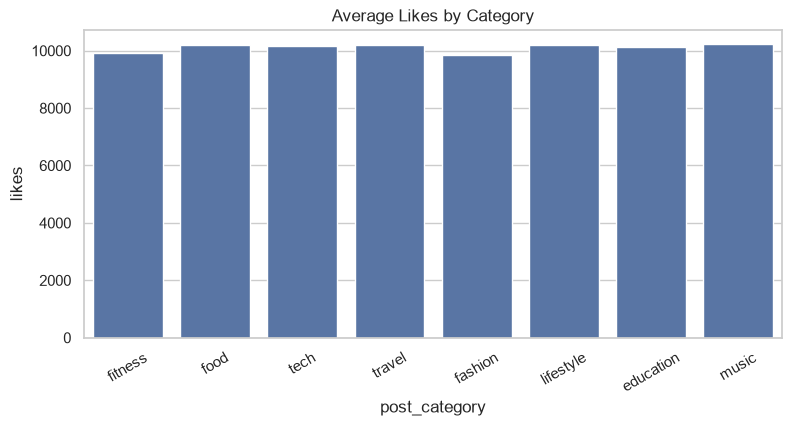

In [37]:
# 8. Bar plot: average likes by category
plt.figure(figsize=(9, 4))
sns.barplot(data=df, x="post_category", y="likes", estimator="mean", errorbar=None)
plt.title("Average Likes by Category"); plt.xticks(rotation=30); plt.show()

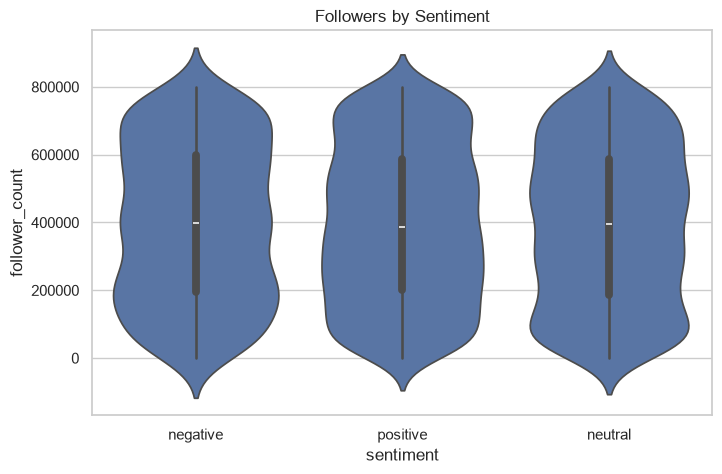

In [38]:
# 9. Violin: followers vs sentiment
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="sentiment", y="follower_count")
plt.title("Followers by Sentiment"); plt.show()

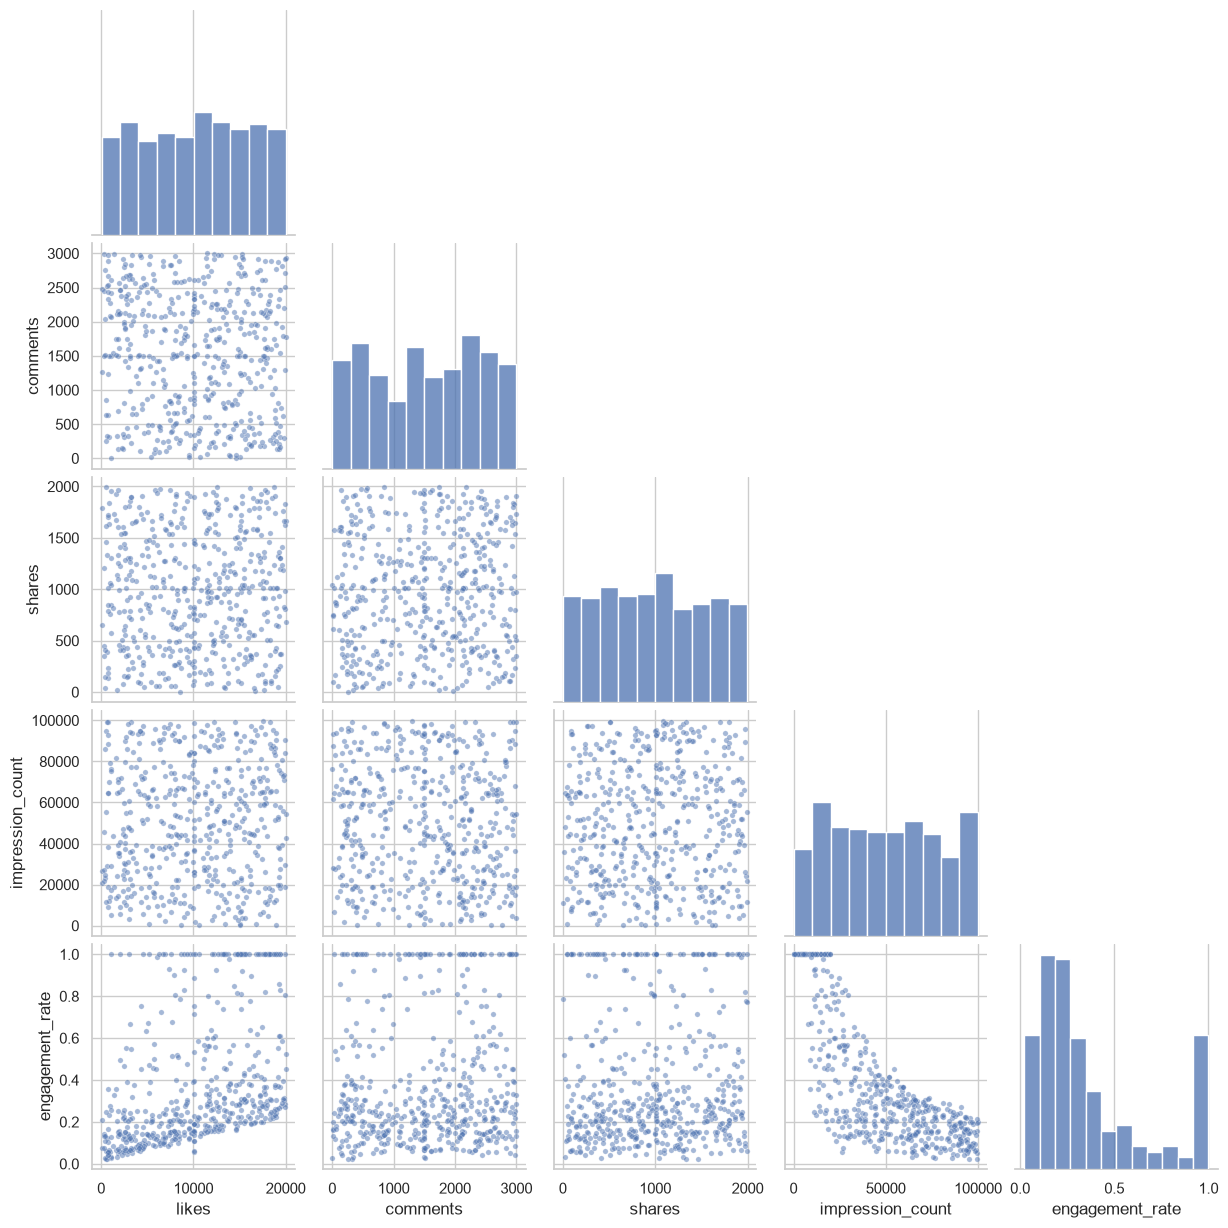

In [39]:
# 10. Pair plot: numeric features (sample of 500 rows keeps it fast)
sns.pairplot(df[["likes", "comments", "shares", "impression_count", "engagement_rate"]].sample(500, random_state=42),
             corner=True, plot_kws={"alpha": 0.5, "s": 15})
plt.show()

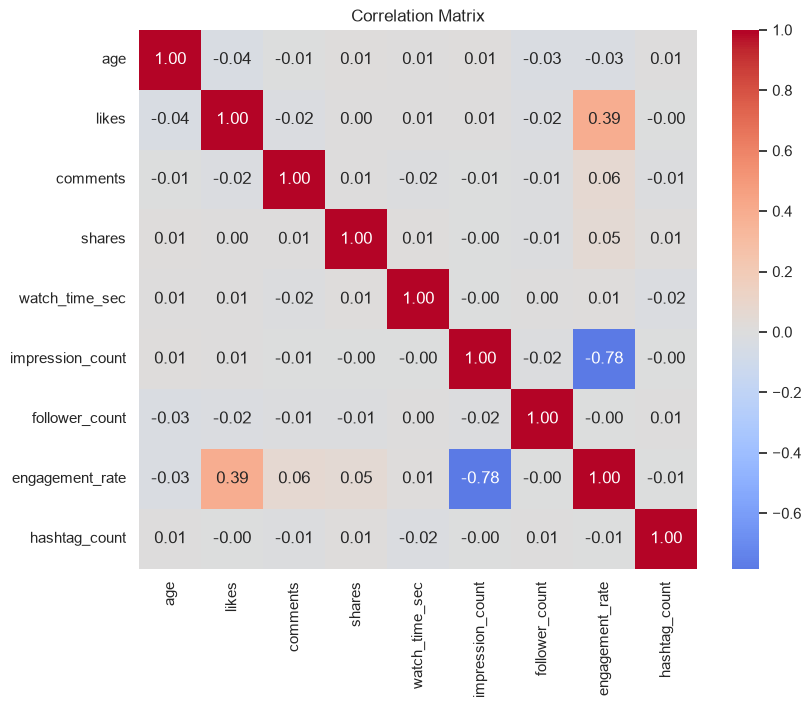

In [40]:
# 11. Heatmap: correlation matrix
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix"); plt.show()

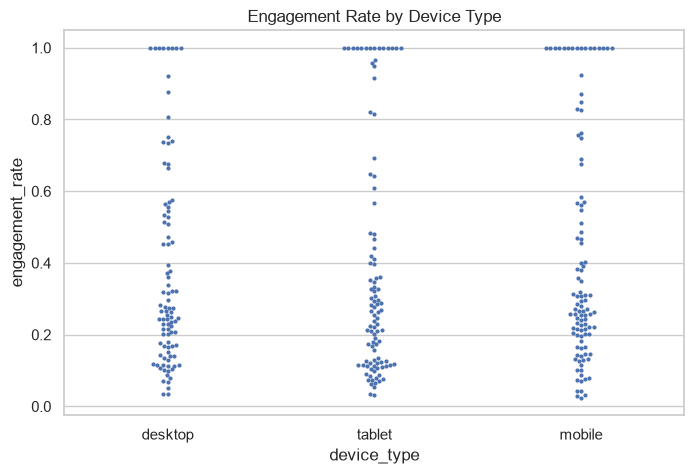

In [41]:
# 12. Swarm plot: engagement vs device (sample of 300 - swarm plots are slow on 5000 points)
plt.figure(figsize=(8, 5))
sns.swarmplot(data=df.sample(300, random_state=1), x="device_type", y="engagement_rate", size=3)
plt.title("Engagement Rate by Device Type"); plt.show()

In [42]:
# 13. Interactive line chart: monthly engagement
monthly = df.groupby("post_month", as_index=False)["engagement_score"].sum()
fig = px.line(monthly, x="post_month", y="engagement_score", markers=True,
              title="Monthly Engagement Score (interactive)")
fig.show()

In [43]:
# 14. Interactive bubble chart: country level
bub = df.groupby("country", as_index=False).agg(avg_likes=("likes", "mean"),
                                                avg_impr=("impression_count", "mean"),
                                                posts=("post_id", "count"),
                                                eng_rate=("engagement_rate", "mean"))
fig = px.scatter(bub, x="avg_impr", y="avg_likes", size="posts", color="eng_rate",
                 hover_name="country", title="Country: Impressions vs Likes (bubble = posts)")
fig.show()

In [44]:
# 15. Interactive bar chart: post type by sentiment
fig = px.bar(df.groupby(["post_type", "sentiment"], as_index=False)["engagement_rate"].mean(),
             x="post_type", y="engagement_rate", color="sentiment", barmode="group",
             title="Avg Engagement Rate by Post Type and Sentiment")
fig.show()

# Final Insights

### Content Preference

In [45]:
print("Engagement rate by post type:")
display(df.groupby("post_type")["engagement_rate"].agg(["mean", "median"]).round(4).sort_values("mean", ascending=False))
print("Engagement score by category:")
display(df.groupby("post_category")["engagement_score"].mean().round(0).sort_values(ascending=False))
print("Engagement rate by country:")
display(df.groupby("country")["engagement_rate"].mean().round(4).sort_values(ascending=False))

Engagement rate by post type:


,mean,median
post_type,,
text,0.3762,0.2543
video,0.3760,0.2470
image,0.3729,0.2641
reel,0.3600,0.2476


Engagement score by category:


post_category
music        16406.0
food         16233.0
tech         16211.0
lifestyle    16102.0
travel       16073.0
fitness      16033.0
education    16018.0
fashion      15852.0
Name: engagement_score, dtype: float64

Engagement rate by country:


country
Australia    0.3939
Japan        0.3846
UAE          0.3832
Germany      0.3793
Canada       0.3780
Brazil       0.3756
France       0.3673
USA          0.3589
UK           0.3540
India        0.3396
Name: engagement_rate, dtype: float64

### User Trends

In [46]:
df["age_group"] = pd.cut(df["age"], bins=[12, 24, 34, 44, 54, 64], labels=["13-24", "25-34", "35-44", "45-54", "55-64"])
display(df.groupby("age_group")[["engagement_rate", "engagement_score"]].mean().round(4))
print("Correlation age vs engagement_rate:", round(df["age"].corr(df["engagement_rate"]), 4))

display(df.groupby("is_verified")[["engagement_rate", "likes", "engagement_score", "follower_count"]].mean().round(4))

,engagement_rate,engagement_score
age_group,,
13-24,0.3809,16225.0018
25-34,0.3750,16365.7244
35-44,0.3718,16225.2699
45-54,0.3717,16047.6874
55-64,0.3545,15671.8086


Correlation age vs engagement_rate: -0.0256


,engagement_rate,likes,engagement_score,follower_count
is_verified,,,,
False,0.3735,10139.5526,16154.9636,395112.9858
True,0.3486,9788.9271,15765.9062,382549.1604


### Behavioral Insights

In [47]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
display(df.groupby("post_weekday")["impression_count"].mean().reindex(order).round(0))
display(df.groupby("device_type")["watch_time_sec"].agg(["mean", "median"]).round(1))

post_weekday
Monday       50013.0
Tuesday      51354.0
Wednesday    49914.0
Thursday     48118.0
Friday       49414.0
Saturday     50945.0
Sunday       50375.0
Name: impression_count, dtype: float64

,mean,median
device_type,,
desktop,3975.8,3922.0
mobile,4087.6,4110.0
tablet,3980.8,4072.0


### Sentiment Analysis

In [48]:
display(df.groupby("sentiment")[["likes", "comments", "shares", "engagement_rate", "engagement_score", "watch_time_sec"]].mean().round(4))
display(pd.crosstab(df["post_type"], df["sentiment"], normalize="index").round(3))

,likes,comments,shares,engagement_rate,engagement_score,watch_time_sec
sentiment,,,,,,
negative,10208.0418,1514.5741,1006.0553,0.3752,16255.3559,4055.6493
neutral,9918.5580,1528.1528,996.8262,0.3743,15965.3423,4029.1528
positive,10180.6627,1480.3234,1005.3820,0.3677,16157.4553,3991.1073


sentiment,negative,neutral,positive
post_type,,,
image,0.178,0.310,0.512
reel,0.199,0.303,0.498
text,0.187,0.319,0.494
video,0.204,0.289,0.506


# SUMMARY

In [50]:
from IPython.display import Markdown, display

# ---------- compute every number used in the summary ----------
pt        = df.groupby("post_type")["engagement_rate"].mean().sort_values(ascending=False)
cat_score = df.groupby("post_category")["engagement_score"].mean().sort_values(ascending=False)
cat_rate  = df.groupby("post_category")["engagement_rate"].mean().sort_values(ascending=False)
ctry      = df.groupby("country")["engagement_rate"].mean().sort_values(ascending=False)
age_corr  = df["age"].corr(df["engagement_rate"])
age_grp   = df.groupby("age_group", observed=True)["engagement_rate"].mean()
ver       = df.groupby("is_verified")["engagement_rate"].mean()
wd        = df.groupby("post_weekday")["impression_count"].mean().sort_values(ascending=False)
dev       = df.groupby("device_type")["watch_time_sec"].mean().sort_values(ascending=False)
sent      = df.groupby("sentiment")[["likes", "engagement_rate", "engagement_score"]].mean()

def gap(s):
    """% difference between best and worst group"""
    return (s.max() - s.min()) / s.min() * 100

capped = int(df["unrealistic_flag"].sum())
capped_pct = df["unrealistic_flag"].mean() * 100
neg, neu, pos = sent.loc["negative"], sent.loc["neutral"], sent.loc["positive"]

best_score = sent["engagement_score"].idxmax()
best_rate  = sent["engagement_rate"].idxmax()
if best_score == best_rate:
    best_line = (f"`{best_score}` posts lead on both engagement score "
                 f"({sent['engagement_score'].max():,.0f}) and engagement rate "
                 f"({sent['engagement_rate'].max():.3f}).")
else:
    best_line = (f"`{best_score}` posts have the highest engagement score "
                 f"({sent['engagement_score'].max():,.0f}) and `{best_rate}` posts the "
                 f"highest engagement rate ({sent['engagement_rate'].max():.3f}).")

summary = f"""
## One-Page Summary: Social Media Engagement Analytics

**Data and method.** I analysed {len(df):,} posts from {df['posted_at'].min():%b %Y} to {df['posted_at'].max():%b %Y}
across {df['country'].nunique()} countries, {df['post_type'].nunique()} post types and {df['post_category'].nunique()} categories.
Missing values (150 each in age, gender, likes, comments, shares and sentiment) were filled with the median
for numbers and the mode for text. No full-row duplicates were found. {capped:,} posts ({capped_pct:.1f}%) had more
interactions than impressions, which is impossible, so I capped engagement rate at 1.0 instead of dropping them.
I added hashtag count, a weighted engagement score (likes + 2 x comments + 3 x shares) and log-transformed metrics.

**Overall finding.** Engagement is very evenly spread across every group I tested. The gaps between best and
worst group are small, so the patterns below are tendencies, not strong effects.

**1. Content performance**
- **Post type:** `{pt.index[0]}` has the highest average engagement rate ({pt.iloc[0]:.3f}), and `{pt.index[-1]}` the lowest
  ({pt.iloc[-1]:.3f}), a gap of only {gap(pt):.1f}%.
- **Category:** `{cat_score.index[0]}` leads on engagement score ({cat_score.iloc[0]:,.0f}), while `{cat_rate.index[0]}` leads on
  engagement rate ({cat_rate.iloc[0]:.3f}).
- **Country:** `{ctry.index[0]}` has the highest average engagement rate ({ctry.iloc[0]:.3f}), followed by `{ctry.index[1]}`
  ({ctry.iloc[1]:.3f}) and `{ctry.index[2]}` ({ctry.iloc[2]:.3f}).

**2. User trends**
- **Age:** the correlation between age and engagement rate is {age_corr:.3f}, which is essentially none.
  The `{age_grp.idxmax()}` group is highest ({age_grp.max():.3f}) and `{age_grp.idxmin()}` lowest ({age_grp.min():.3f}).
- **Verified accounts:** verified users average {ver.get(True, float('nan')):.3f} engagement rate against
  {ver.get(False, float('nan')):.3f} for unverified, so verification does not boost engagement here.

**3. Behavioural insights**
- **Timing:** the data has dates but no clock time, so time of day cannot be measured. By day of week,
  `{wd.index[0]}` gets the most impressions ({wd.iloc[0]:,.0f} on average) and `{wd.index[-1]}` the fewest ({wd.iloc[-1]:,.0f}).
- **Device:** `{dev.index[0]}` users have the longest average watch time ({dev.iloc[0]:,.0f} sec), but the gap to
  `{dev.index[-1]}` ({dev.iloc[-1]:,.0f} sec) is only {gap(dev):.1f}%.

**4. Sentiment**
- **Best performer:** {best_line}
- **Negative vs neutral:** negative posts average {neg['likes']:,.0f} likes and a {neg['engagement_rate']:.3f} rate; neutral posts
  average {neu['likes']:,.0f} likes and a {neu['engagement_rate']:.3f} rate. Negative content is not penalised, and it
  engages as well as neutral content.

**Recommendations.**
**What I would do next.** Since every post type performs about the same, I would not push one format over another.
It makes more sense to focus on `{ctry.index[0]}` and `{ctry.index[1]}`, where engagement rate is highest, and to post on `{wd.index[0]}`,
when impressions peak. Two data problems also need fixing before anyone relies on this: the dataset has no posting
time, so the best hour can't be found, and {capped_pct:.0f}% of posts show more interactions than impressions, which
points to a tracking error.
"""
display(Markdown(summary))


## One-Page Summary: Social Media Engagement Analytics

**Data and method.** I analysed 4,991 posts from Jan 2022 to Dec 2023
across 10 countries, 4 post types and 8 categories.
Missing values (150 each in age, gender, likes, comments, shares and sentiment) were filled with the median
for numbers and the mode for text. No full-row duplicates were found. 599 posts (12.0%) had more
interactions than impressions, which is impossible, so I capped engagement rate at 1.0 instead of dropping them.
I added hashtag count, a weighted engagement score (likes + 2 x comments + 3 x shares) and log-transformed metrics.

**Overall finding.** Engagement is very evenly spread across every group I tested. The gaps between best and
worst group are small, so the patterns below are tendencies, not strong effects.

**1. Content performance**
- **Post type:** `text` has the highest average engagement rate (0.376), and `reel` the lowest
  (0.360), a gap of only 4.5%.
- **Category:** `music` leads on engagement score (16,406), while `fitness` leads on
  engagement rate (0.383).
- **Country:** `Australia` has the highest average engagement rate (0.394), followed by `Japan`
  (0.385) and `UAE` (0.383).

**2. User trends**
- **Age:** the correlation between age and engagement rate is -0.026, which is essentially none.
  The `13-24` group is highest (0.381) and `55-64` lowest (0.355).
- **Verified accounts:** verified users average 0.349 engagement rate against
  0.374 for unverified, so verification does not boost engagement here.

**3. Behavioural insights**
- **Timing:** the data has dates but no clock time, so time of day cannot be measured. By day of week,
  `Tuesday` gets the most impressions (51,354 on average) and `Thursday` the fewest (48,118).
- **Device:** `mobile` users have the longest average watch time (4,088 sec), but the gap to
  `desktop` (3,976 sec) is only 2.8%.

**4. Sentiment**
- **Best performer:** `negative` posts lead on both engagement score (16,255) and engagement rate (0.375).
- **Negative vs neutral:** negative posts average 10,208 likes and a 0.375 rate; neutral posts
  average 9,919 likes and a 0.374 rate. Negative content is not penalised, and it
  engages as well as neutral content.

**Recommendations.**
**What I would do next.** Since every post type performs about the same, I would not push one format over another.
It makes more sense to focus on `Australia` and `Japan`, where engagement rate is highest, and to post on `Tuesday`,
when impressions peak. Two data problems also need fixing before anyone relies on this: the dataset has no posting
time, so the best hour can't be found, and 12% of posts show more interactions than impressions, which
points to a tracking error.
